In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("lung_cancer.csv")


df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


Business Scenario (Consulting-style)

A healthcare organization wants to proactively identify patients at elevated risk of lung cancer so it can prioritize early screening outreach and preventive care programs. Screening resources are limited, so the organization needs a reliable way to rank and target high-risk individuals using demographic, lifestyle, environmental, and clinical indicators.

Key Stakeholders:

Executive sponsor (CMO / VP of Population Health)

Clinical leadership (Pulmonology / Primary Care)

Care management teams (nurses / outreach coordinators)

Analytics team (monitoring + model updates)

Patients (impacted by screening decisions)

Business Objective: Improve screening efficiency by targeting highest-risk individuals first.

Model Objective: Predict lung_cancer_risk (0/1) to support risk stratification (decision support, not diagnosis)

Success Metrics:

Primary: PR-AUC (good for imbalanced classification)

Operational: Recall@TopK (ex: capture as many true high-risk patients as possible in the top 20% flagged)

Secondary: Recall, Precision, F1, ROC-AUC


In [2]:
print("Shape:", df.shape)
display(df.info())

# Missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

Shape: (5000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null

None

,0


lung_cancer_risk
0    3756
1    1244
Name: count, dtype: int64
lung_cancer_risk
0    0.7512
1    0.2488
Name: proportion, dtype: float64


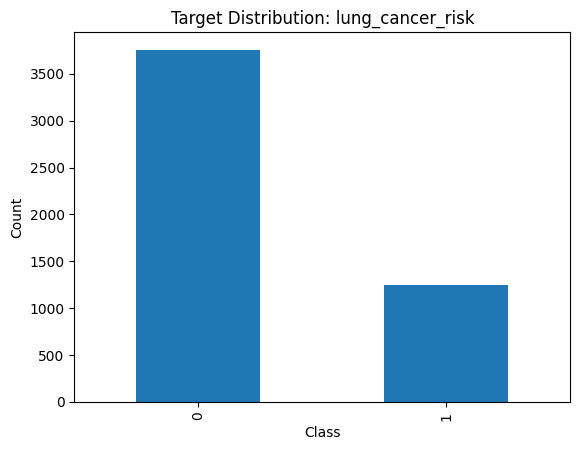

In [3]:
target_col = "lung_cancer_risk"

counts = df[target_col].value_counts()
props = df[target_col].value_counts(normalize=True)

print(counts)
print(props)

plt.figure()
counts.plot(kind="bar")
plt.title("Target Distribution: lung_cancer_risk")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,54.5664,11.932731,18.0,47.0,55.0,62.00,90.0
gender,5000.0,0.4882,0.499911,0.0,0.0,0.0,1.00,1.0
education_years,5000.0,11.5104,2.953987,5.0,10.0,11.0,13.25,20.0
income_level,5000.0,2.5544,0.982667,1.0,2.0,3.0,3.00,5.0
smoker,5000.0,0.4548,0.498003,0.0,0.0,0.0,1.00,1.0
smoking_years,5000.0,8.8222,11.651598,0.0,0.0,0.0,18.00,52.0
cigarettes_per_day,5000.0,6.6856,9.032888,0.0,0.0,0.0,14.00,44.0
pack_years,5000.0,6.2490,9.964901,0.0,0.0,0.0,10.00,60.0
passive_smoking,5000.0,0.3476,0.476256,0.0,0.0,0.0,1.00,1.0
air_pollution_index,5000.0,64.2788,19.479809,20.0,51.0,64.0,78.00,130.0


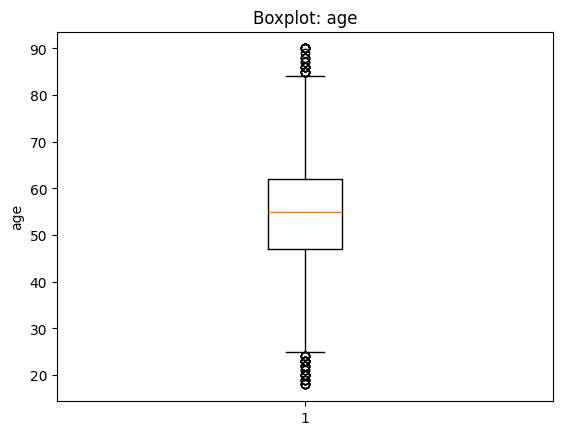

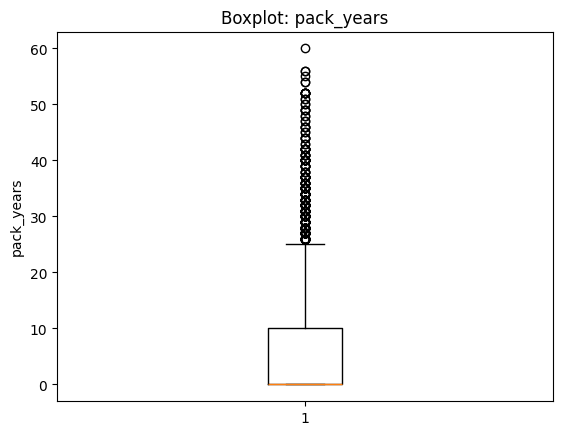

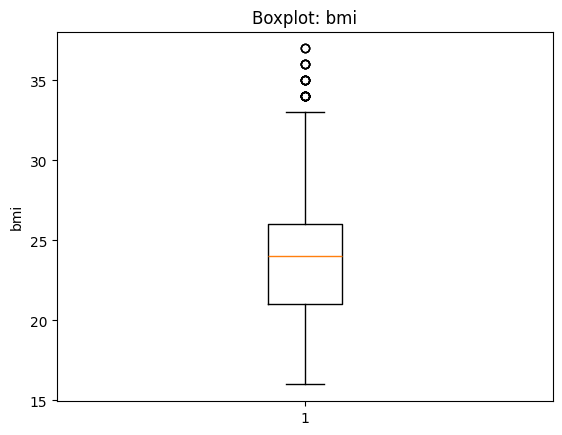

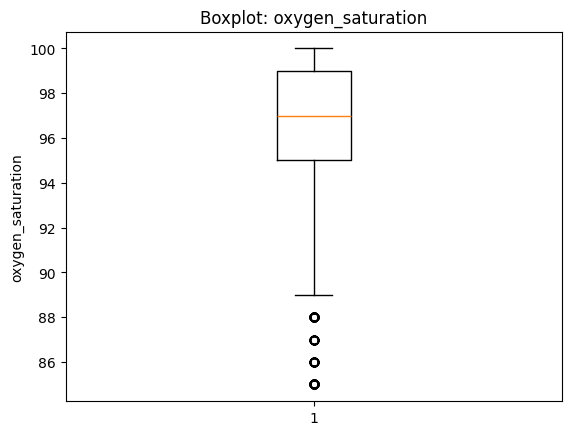

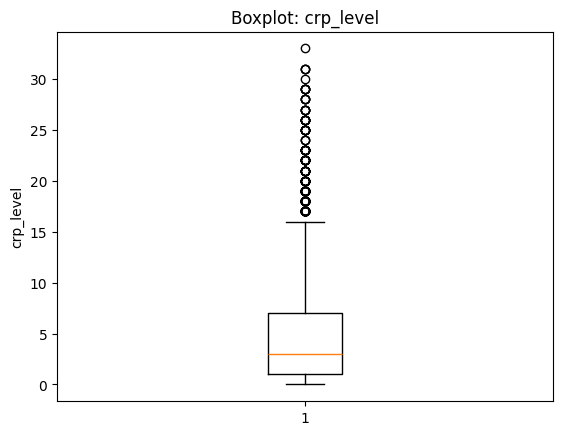

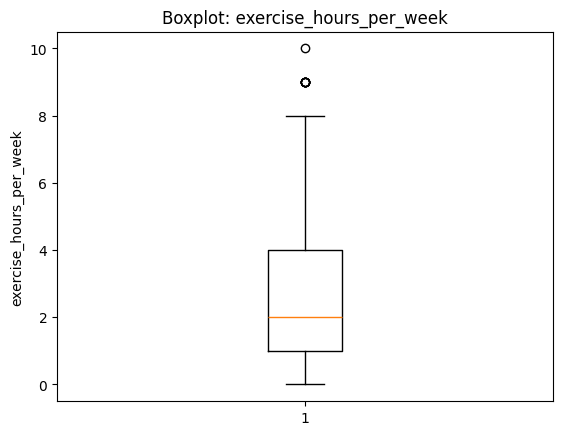

In [5]:
num_cols_to_plot = ["age", "pack_years", "bmi", "oxygen_saturation", "crp_level", "exercise_hours_per_week"]

for col in num_cols_to_plot:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()

lung_cancer_risk,0,1
age,53.992812,56.298232
pack_years,1.485623,20.631029
bmi,23.658946,23.441318
oxygen_saturation,97.593983,91.545820
crp_level,2.198349,11.825563


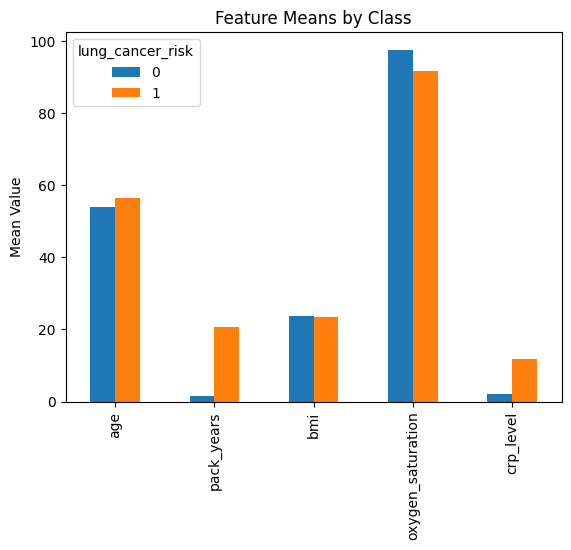

In [6]:
numeric_cols = df.drop(columns=[target_col]).columns.tolist()

# show mean per class for a handful
cols = ["age", "pack_years", "bmi", "oxygen_saturation", "crp_level"]
group_means = df.groupby(target_col)[cols].mean().T
display(group_means)

group_means.plot(kind="bar")
plt.title("Feature Means by Class")
plt.ylabel("Mean Value")
plt.show()

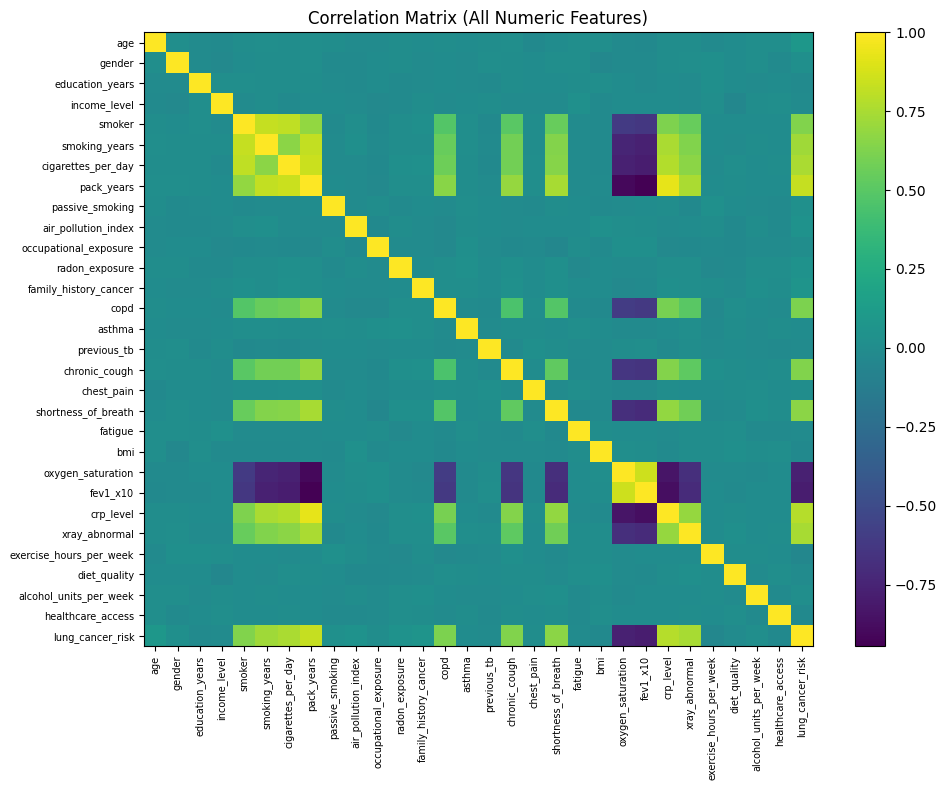

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Correlation Matrix (All Numeric Features)")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.tight_layout()
plt.show()

EDA Conclusions

The exploratory data analysis showed that this dataset is well suited for predicting lung cancer risk. The target variable (lung_cancer_risk) is clearly defined, and both high-risk and low-risk groups are well represented, making this an appropriate classification problem.
Several features showed strong relationships with lung cancer risk. Variables related to smoking behavior, age, and respiratory health differed noticeably between high-risk and low-risk individuals. These patterns align with what is already known about lung cancer risk factors and suggest that the data contains meaningful signal for modeling.
The dataset includes a mix of numeric and categorical features, which supported the use of a preprocessing pipeline to handle scaling, missing values, and categorical encoding in a consistent and reproducible way. Some outliers were observed in medical measurements, but these values appeared realistic and were kept in the data.
Correlation analysis showed that some health-related variables are closely related to each other. This was considered when selecting models and highlighted the importance of using interpretable methods.
Finally, it is important to note that the target represents a risk classification rather than a confirmed diagnosis. Because of this, some features may be closely tied to how the risk label was created, which helps explain the strong separation seen in the data.
Overall, the EDA confirmed that the dataset is appropriate for lung cancer risk prediction and provided guidance for the modeling and evaluation steps that followed.